# Modelo Red Neuronal en cascada
## Primera parte detecta si hay un viaje y sino lo hay se pasa a otra red

De momento sin SMOTE

In [1]:
version = "8_1_first"

In [2]:
import matplotlib.pyplot as plt

def show_history(history, model_name: str):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10))  # 2 filas, 1 columna

    # Pérdida (loss)
    ax1.plot(history.history['loss'],     label='Training Loss',  color='green')
    ax1.plot(history.history['val_loss'], label='Validation Loss', color='blue')
    ax1.set_title('Loss evolution')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()

    # Precisión (accuracy)
    ax2.plot(history.history['accuracy'],     label='Training Accuracy',  color='green')
    ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue')
    ax2.set_title('Accuracy evolution')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    # Título global
    fig.suptitle(model_name, fontsize=16)

    # Ajustar márgenes
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

In [3]:
import pickle
import pandas as pd
import numpy as np
import json

pd.set_option("display.max_rows", None)   # Muestra todas las filas
pd.set_option("display.max_columns", None)  # Muestra todas las columnas
pd.set_option("display.width", None)     # No corta la tabla en varias líneas
pd.set_option("display.max_colwidth", None)  # Muestra el contenido de celdas completo

In [4]:
with open("../../data/normalized/df_normalized.pk1", "rb") as f:
    df_data = pickle.load(f)

In [5]:
df_model = df_data.drop(columns=[
    "ride_id",
    "ended_at",
    "time_hms_ms",
    "member_casual",
    "start_station_id",
    "end_station_id",
    "month",
    "day",
    "temperature",
    "wind_speed",
    "precipitation",
    "relative_humidity",
    "snow_depth",
    "hour_float"
])

In [6]:
# Se redonde al minuto mas cercano
df_data["started_minute"] = df_data["started_at"].dt.round("min")

In [7]:
df_agg = df_data.groupby([
    "start_station_idx",
    "end_station_idx",
    "started_minute"
]).agg(
    n_viajes=("ride_id", "count"),
    year=("year", "first"),
    temp_std=("temp_std", "first"),
    wind_std=("wind_std", "first"),
    rel_humidity_std=("rel_humidity_std", "first"),
    precipitation_std=("precipitation_std", "first"),
    snow_depth_std=("snow_depth_std", "first"),
    hour_sin=("hour_sin", "first"),
    hour_cos=("hour_cos", "first"),
    month_sin=("month_sin", "first"),
    month_cos=("month_cos", "first"),
    event=("event", "any"),  # True si al menos un dato es true
    normal_day=("day_type_Normal", "any"),  # True si al menos un dato es true
    weekend_day=("day_type_Weekend", "any"),  # True si al menos un dato es true
    holiday_day=("day_type_Holiday", "any"),  # True si al menos un dato es true
    #member_casual=("member_casual_bool", "any"),  # True si al menos un dato es true
    #classic_bike=("rideable_type_classic_bike", "any"),  # True si al menos un dato es true
    #docked_bike=("rideable_type_docked_bike", "any"),  # True si al menos un dato es true
    #electric_bike=("rideable_type_electric_bike", "any"),  # True si al menos un dato es true
    #duration_min_mean=("duration_min", "mean"),
).reset_index()

In [8]:
df_agg.describe()

,start_station_idx,end_station_idx,started_minute,n_viajes,year,temp_std,wind_std,rel_humidity_std,precipitation_std,snow_depth_std,hour_sin,hour_cos,month_sin,month_cos
count,9.073410e+06,9.073410e+06,9073410,9.073410e+06,9.073410e+06,9.073410e+06,9.073410e+06,9.073410e+06,9.073410e+06,9.073410e+06,9.073410e+06,9.073410e+06,9.073410e+06,9.073410e+06
mean,1.451035e+03,1.451958e+03,2023-03-15 06:23:51.479779072,1.048204e+00,2.022696e+03,-1.495024e-02,-1.812192e-03,8.774936e-03,4.883809e-05,1.967412e-03,-3.315338e-01,-2.758742e-01,-9.310089e-02,-2.660463e-01
min,0.000000e+00,0.000000e+00,2022-01-01 00:00:00,1.000000e+00,2.022000e+03,-4.191219e+00,-1.996051e+00,-2.519273e+00,-9.970427e-02,-5.614845e-02,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00
25%,1.358000e+03,1.358000e+03,2022-08-06 17:06:00,1.000000e+00,2.022000e+03,-7.493464e-01,-6.917960e-01,-7.628922e-01,-9.970427e-02,-5.614845e-02,-9.362641e-01,-8.029042e-01,-8.660254e-01,-8.660254e-01
50%,1.447000e+03,1.448000e+03,2023-04-13 19:23:00,1.000000e+00,2.023000e+03,1.895027e-01,-8.000990e-02,1.485145e-02,-9.970427e-02,-5.614845e-02,-6.025698e-01,-3.916012e-01,-2.449294e-16,-5.000000e-01
75%,1.565000e+03,1.565000e+03,2023-09-10 20:57:00,1.000000e+00,2.023000e+03,7.707278e-01,6.198615e-01,7.945084e-01,-9.970427e-02,-5.614845e-02,2.005080e-01,1.192704e-01,5.000000e-01,5.000000e-01
max,1.911000e+03,1.911000e+03,2024-06-01 00:00:00,9.000000e+00,2.024000e+03,2.175728e+00,5.576328e+00,2.359562e+00,6.945283e+01,7.287764e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
std,2.191965e+02,2.176947e+02,NaN,2.348621e-01,6.859159e-01,1.003718e+00,1.000607e+00,9.993908e-01,9.976954e-01,1.017557e+00,6.781692e-01,5.950339e-01,7.072976e-01,6.482914e-01


In [9]:
df_agg.iloc[10000:10010]

,start_station_idx,end_station_idx,started_minute,n_viajes,year,temp_std,wind_std,rel_humidity_std,precipitation_std,snow_depth_std,hour_sin,hour_cos,month_sin,month_cos,event,normal_day,weekend_day,holiday_day
10000,5,1362,2022-06-21 00:57:00,1,2022,1.595537,0.115036,-1.872588,-0.099704,-0.056148,0.246788,0.969070,1.224647e-16,-1.000000e+00,False,True,False,False
10001,5,1362,2022-06-30 23:12:00,1,2022,1.607251,1.549199,-1.694654,-0.099704,-0.056148,-0.208836,0.977951,1.224647e-16,-1.000000e+00,False,True,False,False
10002,5,1362,2022-07-06 21:22:00,1,2022,0.976758,0.449277,0.293232,-0.099704,-0.056148,-0.636639,0.771162,-5.000000e-01,-8.660254e-01,False,True,False,False
10003,5,1362,2022-07-10 10:15:00,1,2022,0.056858,-1.307653,1.096805,-0.099704,-0.056148,0.442419,-0.896808,-5.000000e-01,-8.660254e-01,True,False,True,False
10004,5,1362,2022-07-14 18:18:00,1,2022,1.028438,-0.764584,-0.615571,-0.099704,-0.056148,-0.996974,0.077734,-5.000000e-01,-8.660254e-01,False,True,False,False
10005,5,1362,2022-08-13 14:58:00,1,2022,0.801047,0.344502,-0.797331,-0.099704,-0.056148,-0.700857,-0.713301,-8.660254e-01,-5.000000e-01,False,False,True,False
10006,5,1362,2022-08-22 11:15:00,1,2022,0.212242,-0.741637,1.378055,-0.099704,-0.056148,0.196731,-0.980458,-8.660254e-01,-5.000000e-01,False,True,False,False
10007,5,1362,2022-09-03 13:02:00,1,2022,0.660994,-0.630728,0.861473,-0.099704,-0.056148,-0.266257,-0.963902,-1.000000e+00,-1.836970e-16,True,False,True,False
10008,5,1362,2022-09-20 17:01:00,1,2022,1.279257,0.561730,-0.131514,-0.099704,-0.056148,-0.966768,-0.255657,-1.000000e+00,-1.836970e-16,False,True,False,False
10009,5,1362,2022-10-04 08:27:00,1,2022,-0.664936,-1.996051,0.989662,-0.099704,-0.056148,0.800339,-0.599548,-8.660254e-01,5.000000e-01,False,True,False,False


In [10]:
df_agg['n_viajes'].value_counts(normalize=False)

n_viajes
1    8671457
2     372173
3      24990
4       4098
5        565
6        103
7         19
8          4
9          1
Name: count, dtype: int64

Claramente hay un desajuste de datos

In [11]:
map = df_agg[['n_viajes']].copy()


map['bianry_n_viajes'] = np.where(map['n_viajes'] == 1, 1, 0)

map['bianry_n_viajes'].value_counts(normalize=False)

bianry_n_viajes
1    8671457
0     401953
Name: count, dtype: int64

Se puede observar que las veces que se realiza un viaje solo son mucho mayores que las veces que se realizan varios

## Se divide la cantidad de viajes 1 en varias subclases

In [12]:
df_class_1 = df_agg[df_agg['n_viajes'] == 1]

In [13]:
with open("../../data/normalized/le_station_encoder.pkl", "rb") as f:
    le_station = pickle.load(f)
    
num_stations = len(le_station.classes_)

In [ ]:
import pandas as pd

df_class_1 = df_agg[df_agg['n_viajes'] == 1].copy()

# Número de grupos deseados (~500k por grupo)
total = len(df_class_1)
grupos = max(1, total // 500_000)

print("Total filas clase 1:", total)
print("Número de grupos:", grupos)

# Creamos un valor numérico para ordenar por hora
df_class_1["minute_value"] = df_class_1["started_minute"].dt.hour * 60 + df_class_1["started_minute"].dt.minute

# Agrupamos por quantiles (bins iguales por tamaño)
df_class_1["subclass"] = pd.qcut(
    df_class_1["minute_value"],
    q=grupos,
    labels=False,
    duplicates='drop'
) + 1  # Para que empiece en 1

# Insertar la subclase en df_agg
df_agg.loc[df_class_1.index, "subclass"] = df_class_1["subclass"]

# Mostrar tamaños finales
print(df_class_1["subclass"].value_counts().sort_index())


Total filas clase 1: 8671457
Número de grupos: 17
subclass
1     510086
2     510086
3     510085
4     510086
5     510086
6     510085
7     510086
8     510086
9     510085
10    510086
11    510086
12    510085
13    510086
14    510086
15    510085
16    510086
17    510086
Name: count, dtype: int64


### Se añaden el resto de clases (viajes) que faltan

In [15]:
mask = df_agg['n_viajes'] > 1
df_agg.loc[mask, 'subclass'] = df_agg.loc[mask, 'n_viajes'] + 16

# Revisar conteo por subclase
print(df_agg['subclass'].value_counts())

subclass
2.0     510086
8.0     510086
16.0    510086
10.0    510086
11.0    510086
13.0    510086
7.0     510086
14.0    510086
1.0     510086
17.0    510086
5.0     510086
4.0     510086
12.0    510085
3.0     510085
9.0     510085
15.0    510085
6.0     510085
18.0    372173
19.0     24990
20.0      4098
21.0       565
22.0       103
23.0        19
24.0         4
25.0         1
Name: count, dtype: int64


Se agrupan los datos de más de un viaje en un mismo grupo

In [16]:
mask = df_agg['subclass'] >= 18
df_agg.loc[mask, 'subclass'] = 18

# convertir a entero
df_agg['subclass'] = df_agg['subclass'].astype(int)

# Revisar conteo por subclase
print(df_agg['subclass'].value_counts())

subclass
2     510086
8     510086
17    510086
16    510086
10    510086
11    510086
13    510086
7     510086
14    510086
1     510086
4     510086
5     510086
12    510085
9     510085
6     510085
3     510085
15    510085
18    401953
Name: count, dtype: int64


## Obtención de datos

In [17]:
x_context = df_agg.drop(columns=[
    "n_viajes",
    "started_minute",
    "start_station_idx",
    "end_station_idx",
    "subclass"
])

x_start = df_agg[[
    "start_station_idx",
]]

x_end = df_agg[[
    "end_station_idx",
]]

y = df_agg["subclass"]

In [18]:
x_context.head()

,year,temp_std,wind_std,rel_humidity_std,precipitation_std,snow_depth_std,hour_sin,hour_cos,month_sin,month_cos,event,normal_day,weekend_day,holiday_day
0,2022,-1.379839,1.021427,1.326397,-0.099704,-0.056148,-0.416215,-0.909266,0.866025,5.000000e-01,False,False,False,True
1,2022,-0.612834,-0.276355,-0.807078,-0.099704,-0.056148,-0.717569,-0.696487,1.000000,6.123234e-17,False,False,True,False
2,2022,-1.156238,4.113864,0.687365,-0.099704,-0.056148,0.281155,-0.959662,1.000000,6.123234e-17,False,False,True,False
3,2022,-0.424108,-0.883141,-1.019270,-0.099704,-0.056148,-0.972183,-0.234223,1.000000,6.123234e-17,False,False,True,False
4,2022,-0.410327,-0.825775,-1.038403,-0.099704,-0.056148,-0.976781,-0.214238,1.000000,6.123234e-17,False,False,True,False


In [19]:
x_start.head()

,start_station_idx
0,0
1,0
2,0
3,0
4,0


In [20]:
x_end.head()

,end_station_idx
0,0
1,0
2,0
3,0
4,0


In [21]:
y.head()

0     2
1    12
2     8
3    16
4     8
Name: subclass, dtype: int64

In [22]:
# El target empieza en 1 → lo pasamos a 0
y_cls = y - 1

num_classes = y_cls.max() + 1
print("Clases totales:", num_classes)

Clases totales: 18


# Se preparan los datos
-  Primer modelo: Decide si los datos son 1 o no

-  Segundo modelo: Clasifica en el resto de clases

## Primer modelo

In [23]:
from sklearn.model_selection import train_test_split

first_x_ctx_train, first_x_ctx_test, first_x_start_train, first_x_start_test, first_x_end_train, first_x_end_test, first_y_train, first_y_test = \
    train_test_split(x_context, x_start, x_end, y_cls, test_size=0.2, random_state=42, stratify=y_cls)
    
first_x_ctx_train, first_x_ctx_val, first_x_start_train, first_x_start_val, first_x_end_train, first_x_end_val, first_y_train, first_y_val = \
    train_test_split(first_x_ctx_train, first_x_start_train, first_x_end_train, first_y_train, test_size=0.2, random_state=42, stratify=first_y_train)    


### Modelo binario

In [24]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Input, regularizers
from tensorflow.keras.optimizers import Adam
import numpy as np

num_stations = len(le_station.classes_)
num_features = x_context.shape[1]

l2_reg = 1e-4
drop_rate = 0.1

# Inputs
input_start = Input(shape=(1,), name='start_station')
input_end = Input(shape=(1,), name='end_station')
input_context = Input(shape=(num_features,), name='context')

# Embeddings
embed_dim = int(np.ceil(np.sqrt(num_stations)))
embed_start = layers.Embedding(num_stations, embed_dim,embeddings_regularizer=regularizers.l2(l2_reg))(input_start)
embed_end = layers.Embedding(num_stations, embed_dim,embeddings_regularizer=regularizers.l2(l2_reg))(input_end)

# Flatten
flat_start = layers.Flatten()(embed_start)
flat_end = layers.Flatten()(embed_end)

# Concatenate
x = layers.Concatenate()([flat_start, flat_end, input_context])

# Dense Block 1
x = layers.Dense(128,kernel_regularizer=regularizers.l2(l2_reg))(x)
#x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)
x = layers.Dropout(drop_rate)(x)

# Dense Block 2
x = layers.Dense(64,kernel_regularizer=regularizers.l2(l2_reg))(x)
#x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)
x = layers.Dropout(drop_rate)(x)

# Dense Block 3
x = layers.Dense(32,kernel_regularizer=regularizers.l2(l2_reg))(x)
#x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)
x = layers.Dropout(drop_rate)(x)

# Output
output = layers.Dense(num_classes, activation='softmax')(x)

# Model
model = Model(inputs=[input_start, input_end, input_context], outputs=output)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ start_station       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ end_station         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 44)     │     84,128 │ start_station[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 44)     │     84,128 │ end_station[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 44)        │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 44)        │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ context             │ (None, 14)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 102)       │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0],  │
│                     │                   │            │ context[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     13,184 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 128)       │          0 │ dense[0][0]       │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ leaky_re_lu[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 64)        │          0 │ dense_1[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ leaky_re_lu_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 32)        │          0 │ dense_2[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ leaky_re_lu_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 18)        │        594 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 192,370 (751.45 KB)

 Trainable params: 192,370 (751.45 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Entrenamiento
history = model.fit(
    {'start_station': first_x_start_train, 'end_station': first_x_end_train, 'context': first_x_ctx_train},
    first_y_train,
    validation_data=(
        {'start_station': first_x_start_val, 'end_station': first_x_end_val, 'context': first_x_ctx_val},
        first_y_val
    ),    
    batch_size=256,
    epochs=50,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )
    ]
)


Epoch 1/50
22684/22684 ━━━━━━━━━━━━━━━━━━━━ 50s 2ms/step - accuracy: 0.0581 - loss: 4.4797 - val_accuracy: 0.0656 - val_loss: 2.8874
Epoch 2/50
22684/22684 ━━━━━━━━━━━━━━━━━━━━ 49s 2ms/step - accuracy: 0.0653 - loss: 2.8843 - val_accuracy: 0.0658 - val_loss: 2.8811
Epoch 3/50
22684/22684 ━━━━━━━━━━━━━━━━━━━━ 49s 2ms/step - accuracy: 0.0658 - loss: 2.8812 - val_accuracy: 0.0657 - val_loss: 2.8801
Epoch 4/50
22684/22684 ━━━━━━━━━━━━━━━━━━━━ 89s 2ms/step - accuracy: 0.0660 - loss: 2.8803 - val_accuracy: 0.0666 - val_loss: 2.8793
Epoch 5/50
22684/22684 ━━━━━━━━━━━━━━━━━━━━ 52s 2ms/step - accuracy: 0.0660 - loss: 2.8799 - val_accuracy: 0.0664 - val_loss: 2.8790
Epoch 6/50
22684/22684 ━━━━━━━━━━━━━━━━━━━━ 55s 2ms/step - accuracy: 0.0660 - loss: 2.8797 - val_accuracy: 0.0665 - val_loss: 2.8781
Epoch 7/50
22684/22684 ━━━━━━━━━━━━━━━━━━━━ 54s 2ms/step - accuracy: 0.0660 - loss: 2.8796 - val_accuracy: 0.0652 - val_loss: 2.8810
Epoch 8/50
22684/22684 ━━━━━━━━━━━━━━━━━━━━ 54s 2ms/step - accuracy: 

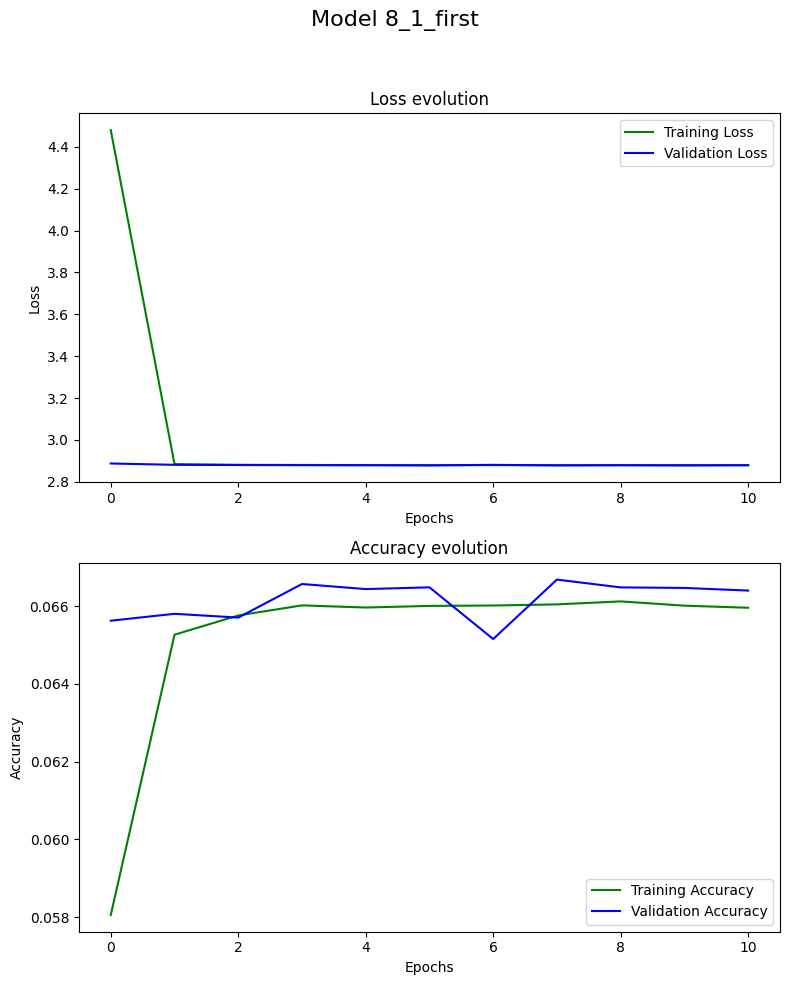

In [26]:
show_history(history, f"Model {version}")

In [27]:
model.save(f"model_{version}.keras")

with open(f'history_{version}.json', 'w') as f:
    json.dump(history.history, f)

### Evaluación del primer modelo

In [28]:
# ---------- Evaluación final sobre el test set real
test_metrics = model.evaluate(
    {'start_station': first_x_start_test, 'end_station': first_x_end_test, 'context': first_x_ctx_test},
    first_y_test,
    verbose=2
)
print("Test metrics (loss, accuracy):", test_metrics)

56709/56709 - 47s - 831us/step - accuracy: 0.0670 - loss: 2.8780
Test metrics (loss, accuracy): [2.8779797554016113, 0.0669919028878212]


### Prediccion del primer modelo

In [29]:
# Predicciones como probabilidades
y_pred_probs = model.predict({
    'start_station': x_start,
    'end_station': x_end,
    'context': x_context
}, batch_size=256)

print("Shape de predicciones:", y_pred_probs.shape)


35444/35444 ━━━━━━━━━━━━━━━━━━━━ 29s 810us/step
Shape de predicciones: (9073410, 18)


In [30]:
# Elegimos la clase con mayor probabilidad
y_pred_classes = np.argmax(y_pred_probs, axis=1)

print("Clases predichas:", np.unique(y_pred_classes))


Clases predichas: [ 3  4  8 12 14 17]


In [31]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Accuracy
acc = accuracy_score(y_cls, y_pred_classes)
print("Accuracy test:", acc)

# Reporte detallado por clase
print(classification_report(y_cls, y_pred_classes))

# Matriz de confusión
cm = confusion_matrix(y_cls, y_pred_classes)
print(cm)


Accuracy test: 0.06681049351897468


c:\Users\burvu\miniconda3\envs\tfm\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\burvu\miniconda3\envs\tfm\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\burvu\miniconda3\envs\tfm\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

              precision    recall  f1-score   support

           0       0.00      0.00      0.00    510086
           1       0.00      0.00      0.00    510086
           2       0.00      0.00      0.00    510085
           3       0.05      0.01      0.02    510086
           4       0.05      0.00      0.00    510086
           5       0.00      0.00      0.00    510085
           6       0.00      0.00      0.00    510086
           7       0.00      0.00      0.00    510086
           8       0.06      0.02      0.03    510085
           9       0.00      0.00      0.00    510086
          10       0.00      0.00      0.00    510086
          11       0.00      0.00      0.00    510085
          12       0.06      0.09      0.07    510086
          13       0.00      0.00      0.00    510086
          14       0.06      0.57      0.10    510085
          15       0.00      0.00      0.00    510086
          16       0.00      0.00      0.00    510086
          17       0.09    

Se elimina la extensión de la categoría 1

In [32]:
y_cls.unique()

array([ 1, 11,  7, 15,  9, 10,  8,  2, 12,  5,  0, 13,  6,  3, 17, 16, 14,
        4])

In [33]:
np.unique(y_pred_classes)

array([ 3,  4,  8, 12, 14, 17])

In [34]:
conteo_clases = y_cls.value_counts()
print(conteo_clases)

subclass
1     510086
7     510086
16    510086
15    510086
9     510086
10    510086
12    510086
6     510086
13    510086
0     510086
3     510086
4     510086
11    510085
8     510085
5     510085
2     510085
14    510085
17    401953
Name: count, dtype: int64


In [35]:
mapping = {
    0: 1,
    1: 1,
    2: 1,
    3: 1,
    4: 1,
    5: 1,
    6: 1,
    7: 1,
    8: 1,
    9: 1,
    10: 1,
    11: 1,
    12: 1,
    13: 1,
    14: 1,
    15: 1,
    16: 1,
    17: 2
}

y_cls_real = y_cls.map(mapping)
y_pred_real = np.vectorize(lambda x: mapping.get(x, x))(y_pred_classes)

print(np.unique(y_pred_real))
print(y_cls_real.unique())

[1 2]
[1 2]


In [36]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Accuracy
acc = accuracy_score(y_cls_real, y_pred_real)
print("Accuracy test:", acc)

# Reporte detallado por clase
print(classification_report(y_cls_real, y_pred_real))

# Matriz de confusión
cm = confusion_matrix(y_cls_real, y_pred_real)
print(cm)

Accuracy test: 0.6966380886568556
              precision    recall  f1-score   support

           1       0.98      0.70      0.82   8671457
           2       0.09      0.62      0.15    401953

    accuracy                           0.70   9073410
   macro avg       0.53      0.66      0.48   9073410
weighted avg       0.94      0.70      0.79   9073410

[[6071521 2599936]
 [ 152591  249362]]


## ---------------

In [37]:
# # ejemplo simplificado (Keras). Ajusta capas, hiperparámetros y callbacks según tu caso.

# import numpy as np
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import confusion_matrix, classification_report
# from tensorflow.keras import layers, models, losses, optimizers

# # X, y reales. Asumimos y tiene valores {1,2,3,4,5}
# # Convertir a binario para stage1: 1 -> 0 (neg), others -> 1 (pos: "no-1")
# y_stage1 = (y != 1).astype(int)

# # Split
# X_train, X_test, y1_train, y1_test, y_train_full, y_test_full = train_test_split(
#     X, y_stage1, y, test_size=0.2, random_state=42, stratify=y
# )

# x_ctx_train, x_ctx_test, x_start_train, x_start_test, x_end_train, x_end_test, y_train, y_test = \
#     train_test_split(x_context, x_start, x_end, y_cls, test_size=0.2, random_state=42, stratify=y_cls)

# # --- Stage 1: binary classifier (priorizar recall de la clase "no-1")
# def build_stage1(input_shape):
#     inp = layers.Input(shape=input_shape)
#     x = layers.Dense(128, activation='relu')(inp)
#     x = layers.BatchNormalization()(x)
#     x = layers.Dropout(0.3)(x)
#     x = layers.Dense(64, activation='relu')(x)
#     out = layers.Dense(1, activation='sigmoid')(x)
#     return models.Model(inp, out)

# m1 = build_stage1(X.shape[1])
# m1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['Recall','Precision'])

# # opcional: usar class weights para priorizar "no-1"
# from sklearn.utils.class_weight import compute_class_weight
# cw = compute_class_weight('balanced', classes=np.unique(y1_train), y=y1_train)
# class_weight_stage1 = {i:w for i,w in enumerate(cw)}

# m1.fit(X_train, y1_train, epochs=10, batch_size=4096, class_weight=class_weight_stage1, validation_split=0.1)

# # --- Stage 2: multiclase sólo con muestras no-1 (las que importan)
# mask_train_no1 = (y_train_full != 1)
# X_train_s2 = X_train[mask_train_no1[:len(X_train)]]  # ajusta si hiciste split distinto
# y_train_s2 = y_train_full[mask_train_no1[:len(X_train)]]

# # reindex labels a 0..K-1 si quieres (por ejemplo map {2->0,3->1,4->2,5->3})
# import numpy as np
# unique_non1 = np.unique(y_train_s2)
# label_map = {lab:i for i,lab in enumerate(unique_non1)}
# y_train_s2_mapped = np.array([label_map[v] for v in y_train_s2])

# def build_stage2(input_shape, n_classes):
#     inp = layers.Input(shape=input_shape)
#     x = layers.Dense(256, activation='relu')(inp)
#     x = layers.BatchNormalization()(x)
#     x = layers.Dropout(0.4)(x)
#     x = layers.Dense(128, activation='relu')(x)
#     out = layers.Dense(n_classes, activation='softmax')(x)
#     return models.Model(inp, out)

# m2 = build_stage2(X.shape[1], len(unique_non1))
# m2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# # Para Stage2 usa oversampling o class weights:
# from sklearn.utils import resample
# # simple upsampling example (balancear por mayoría):
# df_s2 = np.hstack([X_train_s2, y_train_s2_mapped.reshape(-1,1)])
# # ... aquí conviene usar pandas para upsample por clase; omito por brevedad

# # entrena m2 con datos balanceados (o usar class_weight)
# m2.fit(X_train_s2, y_train_s2_mapped, epochs=20, batch_size=2048, validation_split=0.1)

# # --- Inferencia end-to-end en X_test
# probs_stage1 = m1.predict(X_test, batch_size=8192).ravel()
# # elegir umbral que te de recall deseado para detect no-1 (ajustar con validación)
# threshold = 0.2
# mask_pass_to_s2 = probs_stage1 >= threshold

# # preparar inputs para stage2 (mapeo de etiquetas)
# X_for_s2 = X_test[mask_pass_to_s2]
# pred_s2 = None
# if len(X_for_s2)>0:
#     preds_s2_probs = m2.predict(X_for_s2)
#     preds_s2_idx = preds_s2_probs.argmax(axis=1)
#     # map back to original labels
#     inv_map = {v:k for k,v in label_map.items()}
#     preds_s2_labels = np.array([inv_map[i] for i in preds_s2_idx])
# else:
#     preds_s2_labels = np.array([], dtype=int)

# # construir predicciones finales
# y_pred_final = np.ones_like(y_test_full)  # por defecto predice 1
# y_pred_final[mask_pass_to_s2] = preds_s2_labels

# # evaluación end-to-end
# print(classification_report(y_test_full, y_pred_final, digits=4))
# print(confusion_matrix(y_test_full, y_pred_final))
